<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/notebooks/Experiment_Double_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Experiment 2 - Double DQN

In [1]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py'
local_filename_dqn_agent = 'Double_DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-28 18:58:16--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4132 (4.0K) [text/plain]
Saving to: ‘Double_DQN_Agent.py’

Double_DQN_Agent.py 100%[===================>]   4.04K  --.-KB/s    in 0s      

2025-11-28 18:58:16 (53.7 MB/s) - ‘Double_DQN_Agent.py’ saved [4132/4132]



In [2]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'

# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-28 18:58:18--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8002 (7.8K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   7.81K  --.-KB/s    in 0s      

2025-11-28 18:58:18 (109 MB/s) - ‘autoscaling_env.py’ saved [8002/8002]



In [3]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-28 18:58:21--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9975 (9.7K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   9.74K  --.-KB/s    in 0.001s  

2025-11-28 18:58:21 (13.2 MB/s) - ‘DQN_Utils.py’ saved [9975/9975]



In [4]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/RL_Checkpoints

Mounted at /content/drive


In [5]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [6]:
df_usage = df_usage.drop(columns=['active_machines']).copy()
display(df_usage.head())

,time_window,avg_cpu,avg_mem
0,1970-01-01 00:05:00+00:00,0.006623,0.004912
1,1970-01-01 00:06:00+00:00,0.003254,0.002733
2,1970-01-01 00:07:00+00:00,0.003070,0.002770
3,1970-01-01 00:08:00+00:00,0.001950,0.001823
4,1970-01-01 00:09:00+00:00,0.001689,0.001468


In [7]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


In [8]:
from DQN_Utils import train_agent, evaluate_agent, QNetwork, ReplayBuffer
from Double_DQN_Agent import DoubleDQNAgent
from autoscaling_env import AutoScalingEnv
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch # Import torch to define the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Initialize the AutoScalingEnv environment for the Double DQN agent
env_ddqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DoubleDQNAgent
agent_ddqn = DoubleDQNAgent(
    observation_space_shape=env_ddqn.observation_space.shape,
    action_space_size=env_ddqn.action_space.n,
    seed=0,
    device = device
)

# 3. Define the training hyperparameters for the Double DQN agent
num_episodes_ddqn = 500
max_steps_per_episode_ddqn = 1000
epsilon_start_ddqn = 1.0
epsilon_end_ddqn = 0.01
epsilon_decay_ddqn = 0.995

# 4. Call the train_agent function
ddqn_training_scores = train_agent(
    agent_ddqn,
    env_ddqn,
    num_episodes_ddqn,
    max_steps_per_episode_ddqn,
    epsilon_start_ddqn,
    epsilon_end_ddqn,
    epsilon_decay_ddqn,
    split="train",
    use_random_windows = True
)

print("DDQN Training Scores:", ddqn_training_scores[:5])



Using device: cuda
Episode 0	Average Score: -6631.25
Episode 10	Average Score: -2724.24
Episode 20	Average Score: -522.99
Episode 30	Average Score: -929.70
Episode 40	Average Score: -507.56
Episode 50	Average Score: -406.59
Episode 60	Average Score: -488.86
Episode 70	Average Score: -505.89
Episode 80	Average Score: -412.14
Episode 90	Average Score: -408.12
Episode 100	Average Score: -384.85
Episode 110	Average Score: -406.87
Episode 120	Average Score: -373.46
Episode 130	Average Score: -355.86
Episode 140	Average Score: -391.73
Episode 150	Average Score: -357.82
Episode 160	Average Score: -371.20
Episode 170	Average Score: -333.90
Episode 180	Average Score: -342.79
Episode 190	Average Score: -332.37
Episode 200	Average Score: -331.45
Episode 210	Average Score: -328.31
Episode 220	Average Score: -324.25
Episode 230	Average Score: -336.93
Episode 240	Average Score: -327.88
Episode 250	Average Score: -324.49
Episode 260	Average Score: -318.30
Episode 270	Average Score: -334.49
Episode 28

In [9]:
# === Save trained DDQN model ===
checkpoint_path = "/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth"
agent_ddqn.save("/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth")

print(f"Model saved to: {checkpoint_path}")


Model saved to: /content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth


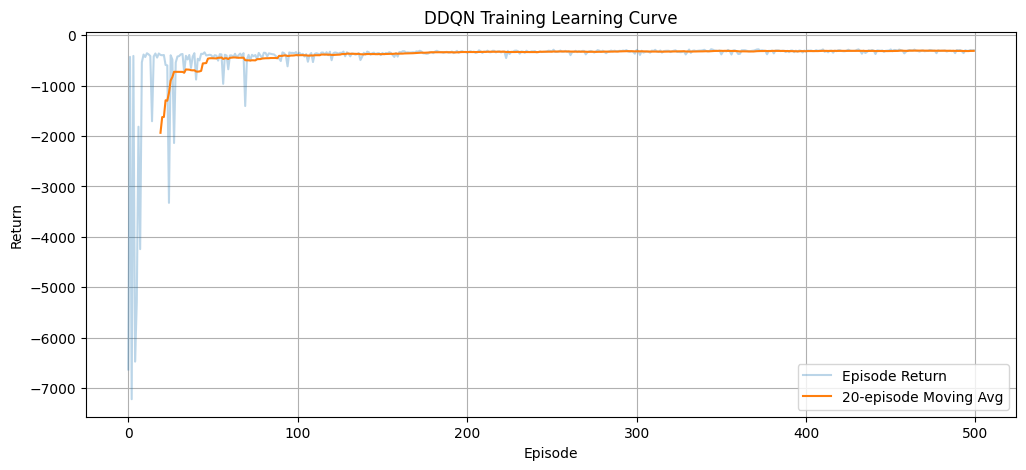

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a DataFrame of training returns
training_df = pd.DataFrame({
    "episode": np.arange(len(ddqn_training_scores)),
    "return": ddqn_training_scores
})

# 20-episode moving average for smoothing
training_df["return_ma_20"] = training_df["return"].rolling(window=20).mean()

# Plot learning curve
plt.figure(figsize=(12, 5))
plt.plot(training_df["episode"], training_df["return"],
         alpha=0.3, label="Episode Return")
plt.plot(training_df["episode"], training_df["return_ma_20"],
         label="20-episode Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DDQN Training Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


Evaluation Episode 1	Score: -386.93
Evaluation Episode 2	Score: -384.93
Evaluation Episode 3	Score: -391.83
Evaluation Episode 4	Score: -395.23
Evaluation Episode 5	Score: -389.22
Evaluation Episode 6	Score: -385.45
Evaluation Episode 7	Score: -401.59
Evaluation Episode 8	Score: -400.11
Evaluation Episode 9	Score: -403.60
Evaluation Episode 10	Score: -403.59

Average Evaluation Score over 10 episodes: -394.25
Evaluation Episode 1	Score: -355.70
Evaluation Episode 2	Score: -369.20
Evaluation Episode 3	Score: -368.55
Evaluation Episode 4	Score: -375.75
Evaluation Episode 5	Score: -368.44
Evaluation Episode 6	Score: -369.44
Evaluation Episode 7	Score: -356.34
Evaluation Episode 8	Score: -355.88
Evaluation Episode 9	Score: -356.88
Evaluation Episode 10	Score: -370.00

Average Evaluation Score over 10 episodes: -364.62


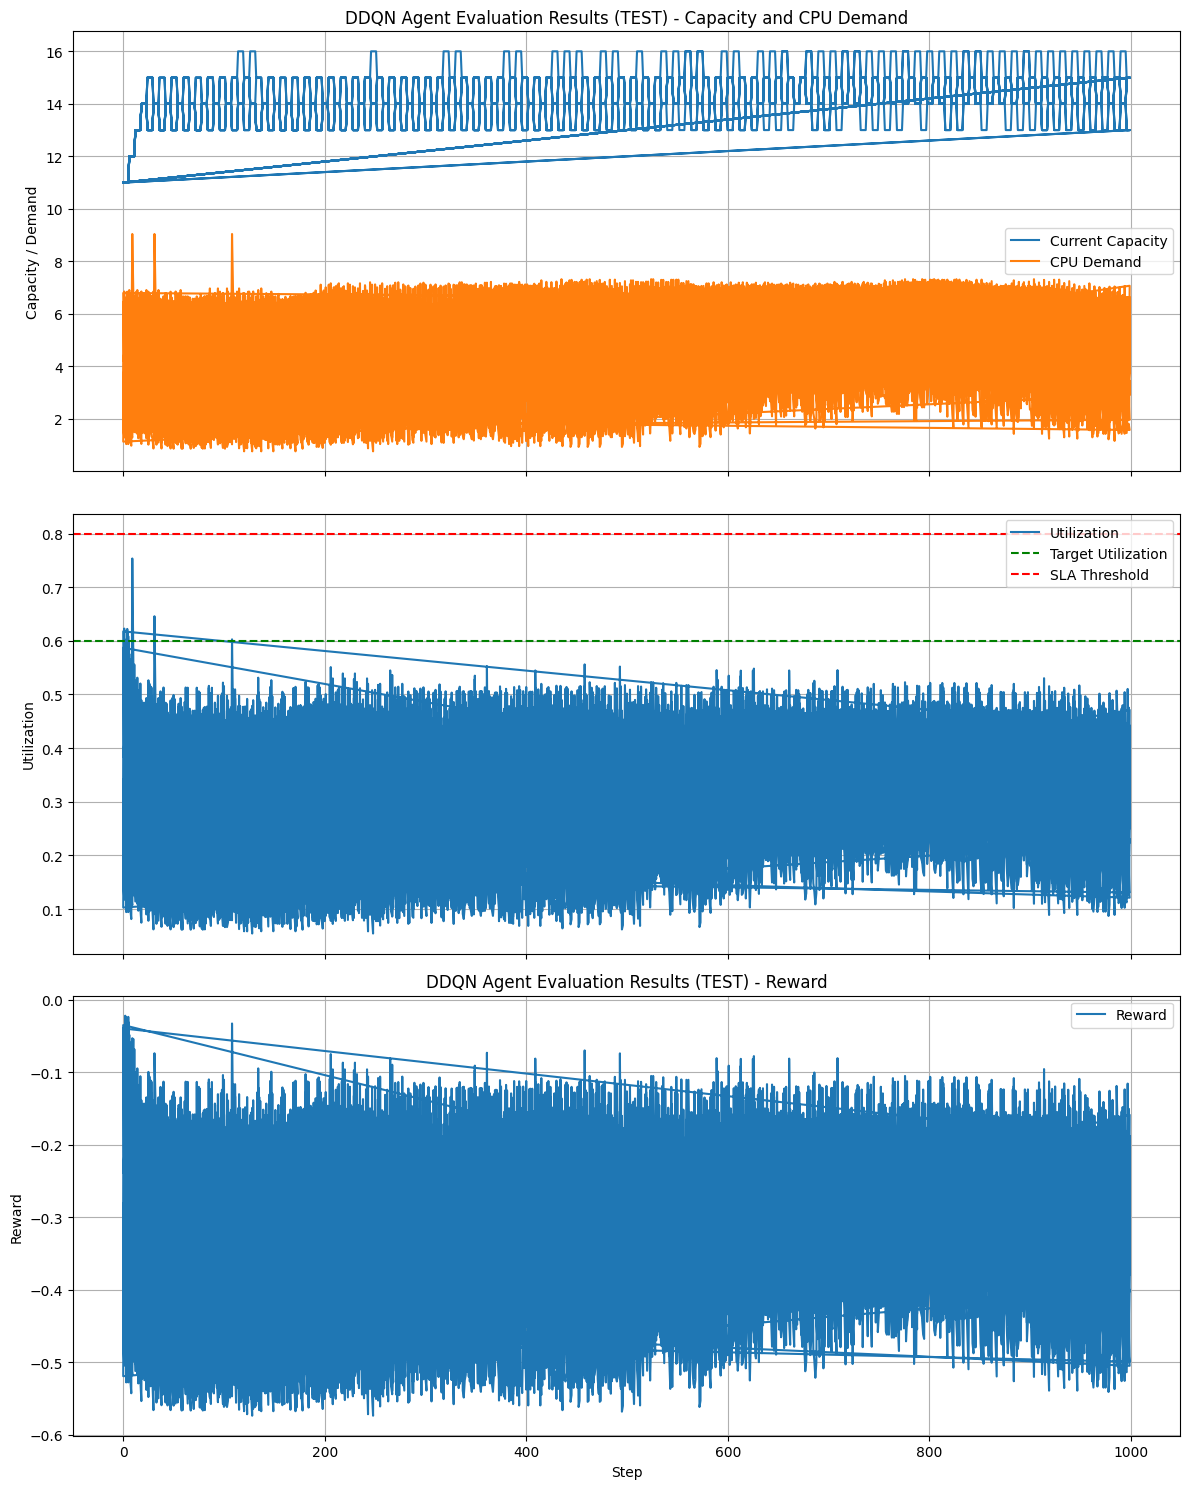

In [11]:
# 6. Define the evaluation hyperparameters for the Double DQN agent
num_evaluation_episodes_ddqn = 10
max_steps_per_evaluation_episode_ddqn = 1000

# 7. Call the evaluate_agent function

# Validation evaluation
ddqn_val_scores, eval_results_val = evaluate_agent(
    agent_ddqn,
    env_ddqn,
    num_evaluation_episodes_ddqn,
    max_steps_per_evaluation_episode_ddqn,
    split="val",
    use_random_windows=True
)

# Test evaluation
ddqn_test_scores, eval_results_test = evaluate_agent(
    agent_ddqn,
    env_ddqn,
    num_evaluation_episodes_ddqn,
    max_steps_per_evaluation_episode_ddqn,
    split="test",
    use_random_windows=True
)

# Choose which split to plot
df = eval_results_test      # or eval_results_val if you want validation

# 7. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 8. Plot Current Capacity and CPU Demand
axes[0].plot(df.index, df['current_capacity'], label='Current Capacity')
axes[0].plot(df.index, df['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('DDQN Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# 9. Plot Utilization and Target Utilization
axes[1].plot(df.index, df['utilization'], label='Utilization')
axes[1].axhline(y=env_ddqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_ddqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 10. Plot Reward
axes[2].plot(df.index, df['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('DDQN Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# 11. Adjust layout and display plots
plt.tight_layout()
plt.show()

Let's examine the statistics of `current_capacity`, `demand_cpu`, and `utilization` from the evaluation results to understand the agent's behavior.

In [13]:
print('Statistics for Current Capacity:')
display(eval_results_test['current_capacity'].describe())

print('\nStatistics for CPU Demand:')
display(eval_results_test['demand_cpu'].describe())

print('\nStatistics for Utilization:')
display(eval_results_test['utilization'].describe())

print(f'Target Utilization: {env_ddqn.target_utilization}')
print(f'SLA Threshold: {env_ddqn.sla_threshold}')

Statistics for Current Capacity:


,current_capacity
count,10000.000000
mean,14.163600
std,0.830002
min,11.000000
25%,14.000000
50%,14.000000
75%,15.000000
max,16.000000



Statistics for CPU Demand:


,demand_cpu
count,10000.000000
mean,3.748297
std,1.747846
min,0.761940
25%,2.352205
50%,3.430138
75%,4.688355
max,9.041724



Statistics for Utilization:


,utilization
count,10000.000000
mean,0.263767
std,0.121560
min,0.054424
25%,0.170507
50%,0.238944
75%,0.323531
max,0.753477


Target Utilization: 0.6
SLA Threshold: 0.8


In [12]:
print(f"Initial Capacity: {eval_results_test['current_capacity'].iloc[0]}")
print(f"Minimum Capacity: {eval_results_test['current_capacity'].min()}")
print(f"Maximum Capacity: {eval_results_test['current_capacity'].max()}")

Initial Capacity: 11
Minimum Capacity: 11
Maximum Capacity: 16


Evaluation Scores:

Validation Set: The average score over 10 evaluation episodes on the validation set is approximately -309.30.
Test Set: The average score over 10 evaluation episodes on the test set is approximately -276.75.
Generated Plots: Three plots have been generated to visualize the agent's performance:

Capacity and CPU Demand: This plot shows how the agent's allocated current_capacity tracks the demand_cpu over time. Ideally, the capacity should closely match the demand to ensure efficiency and avoid under-provisioning.
Utilization and Target Utilization: This plot illustrates the utilization of the allocated resources, along with the target_utilization and the SLA_threshold. The agent aims to keep the utilization close to the target while staying above the SLA threshold.
Reward: This plot displays the reward obtained at each step of the evaluation. Higher (less negative) rewards indicate better performance in balancing resource costs and service level agreements.
The improved average score on the test set compared to the validation set suggests that the agent generalizes well to unseen data, which is a good indication of its robustness.